# Uber Fare Prediction — End-to-End ML Pipeline


**Note on the Task 2 pipeline:** this notebook uses the same steps as Task 2 (cleaning rules, distance and time features, the September 2012 price change, the JFK–Manhattan flag, scaling, encoding, a log target, and Linear Regression, Random Forest and Gradient Boosting). The difference is that every step that changes the inputs now lives inside one scikit-learn Pipeline built from raw trip data. In Task 2, encoding and some features were done outside the pipeline, so the saved model could not take raw input from a user. Here the saved file takes a raw trip directly, which is what the Flask app needs.

## Problem Framing
- **Goal:** predict the fare of an Uber trip in New York before the trip starts.
- **Target:** `fare_amount` (US dollars), so this is a **regression** problem.
- **Inputs a user can give:** pickup and dropoff coordinates, pickup date and time, passenger count, car condition, weather and traffic.
- **Metrics:** MAE (average error in dollars, easy to explain), RMSE (punishes large errors), R² (share of fare variation explained).
- **Baseline:** Linear Regression; any chosen model must beat it on the test set.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split

# same seed everywhere so results can be repeated
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

# load the data
df = pd.read_csv("final_internship_data.csv")
print("Shape:", df.shape)

# types, missing values and ranges
df.info()
display(df.describe().T)

# text labels, to plan the encoding
for col in ["Car Condition", "Weather", "Traffic Condition"]:
    print(col, df[col].unique())

# date format, and latitude near 0.71 means radians (NYC is 40.7 degrees)
print("Date example:", df["pickup_datetime"].iloc[0])
print("Median latitude:", df["pickup_latitude"].median())

Shape: (500000, 26)
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  str    
 1   User Name          500000 non-null  str    
 2   Driver Name        500000 non-null  str    
 3   Car Condition      500000 non-null  str    
 4   Weather            500000 non-null  str    
 5   Traffic Condition  500000 non-null  str    
 6   key                500000 non-null  str    
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  str    
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64 

,count,mean,std,min,25%,50%,75%,max
fare_amount,500000.0,11.358361,9.916617,-44.900000,6.000000,8.500000,12.500000,500.000000
pickup_longitude,500000.0,-1.265712,0.206941,-52.119764,-1.291405,-1.291226,-1.290970,37.360538
pickup_latitude,500000.0,0.696740,0.140909,-54.389440,0.710958,0.711268,0.711520,29.724576
dropoff_longitude,499995.0,-1.265755,0.205903,-59.049665,-1.291393,-1.291197,-1.290908,0.712985
dropoff_latitude,499995.0,0.696675,0.128997,-44.676047,0.710943,0.711277,0.711538,7.061893
passenger_count,500000.0,1.683428,1.307395,0.000000,1.000000,1.000000,2.000000,6.000000
hour,500000.0,13.510834,6.511571,0.000000,9.000000,14.000000,19.000000,23.000000
day,500000.0,15.684206,8.681066,1.000000,8.000000,16.000000,23.000000,31.000000
month,500000.0,6.268650,3.437815,1.000000,3.000000,6.000000,9.000000,12.000000
weekday,500000.0,3.042008,1.949240,0.000000,1.000000,3.000000,5.000000,6.000000


Car Condition <StringArray>
['Very Good', 'Excellent', 'Bad', 'Good']
Length: 4, dtype: str
Weather <StringArray>
['windy', 'cloudy', 'stormy', 'sunny', 'rainy']
Length: 5, dtype: str
Traffic Condition <StringArray>
['Congested Traffic', 'Flow Traffic', 'Dense Traffic']
Length: 3, dtype: str
Date example: 2009-06-15 17:26:21
Median latitude: 0.7112682704787175


## Data Cleaning 
**What:** drop IDs and ready-made columns, drop missing and duplicate rows, convert coordinates to degrees and the date to a real date, and keep only trips inside New York with 1–6 passengers.
**Why:** IDs tell nothing about the fare, ready-made columns will be rebuilt in the pipeline, users type degrees, and points outside NYC or 0 passengers are recording errors.
**Why it matters:** these rules learn nothing from the data, so they are safe before the split, and the app will use the same rules to reject bad input. Fare cleaning waits until after the split.

In [27]:
rows_start = len(df)

# IDs are unique per trip, and the pipeline will rebuild the ready-made columns
df = df.drop(columns=["User ID", "User Name", "Driver Name", "key",
                      "hour", "day", "month", "weekday", "year",
                      "jfk_dist", "ewr_dist", "lga_dist", "sol_dist", "nyc_dist",
                      "distance", "bearing"])

# 5 rows have no dropoff location, and repeated trips would count twice
df = df.dropna().drop_duplicates()

# users type degrees, and the date must be a real date
coords = ["pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude"]
df[coords] = np.degrees(df[coords])
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"].str.replace(" UTC", ""))

# keep trips inside New York with 1 to 6 passengers
df = df[df["pickup_latitude"].between(40.5, 41.0) & df["dropoff_latitude"].between(40.5, 41.0)
        & df["pickup_longitude"].between(-74.3, -73.7) & df["dropoff_longitude"].between(-74.3, -73.7)
        & df["passenger_count"].between(1, 6)]

print("Rows:", rows_start, "->", len(df))
print("Columns:", list(df.columns))
print("Dates:", df["pickup_datetime"].min(), "to", df["pickup_datetime"].max())

Rows: 500000 -> 487243
Columns: ['Car Condition', 'Weather', 'Traffic Condition', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']
Dates: 2009-01-01 00:31:32 to 2015-06-30 23:38:21


## Train/Test Split
**What:** split the data into 80% train and 20% test.
**Why:** the model learns from train only; test is kept for one final check.
**Why it matters:** every step after this that learns from data uses train only, so the test score is honest.

In [29]:
# inputs and target
X = df.drop(columns=["fare_amount"])
y = df["fare_amount"]

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (389794, 9) | Test: (97449, 9)


## EDA (train set only)
**What:** look at the fare distribution, fare vs distance, the price change over time, fares by hour, and airport trips.
**Why:** each pattern we find here becomes a feature in the pipeline, and impossible fares show what label cleaning is needed.
**Why it matters:** features are chosen from evidence, and using only the train set keeps the test set unseen.

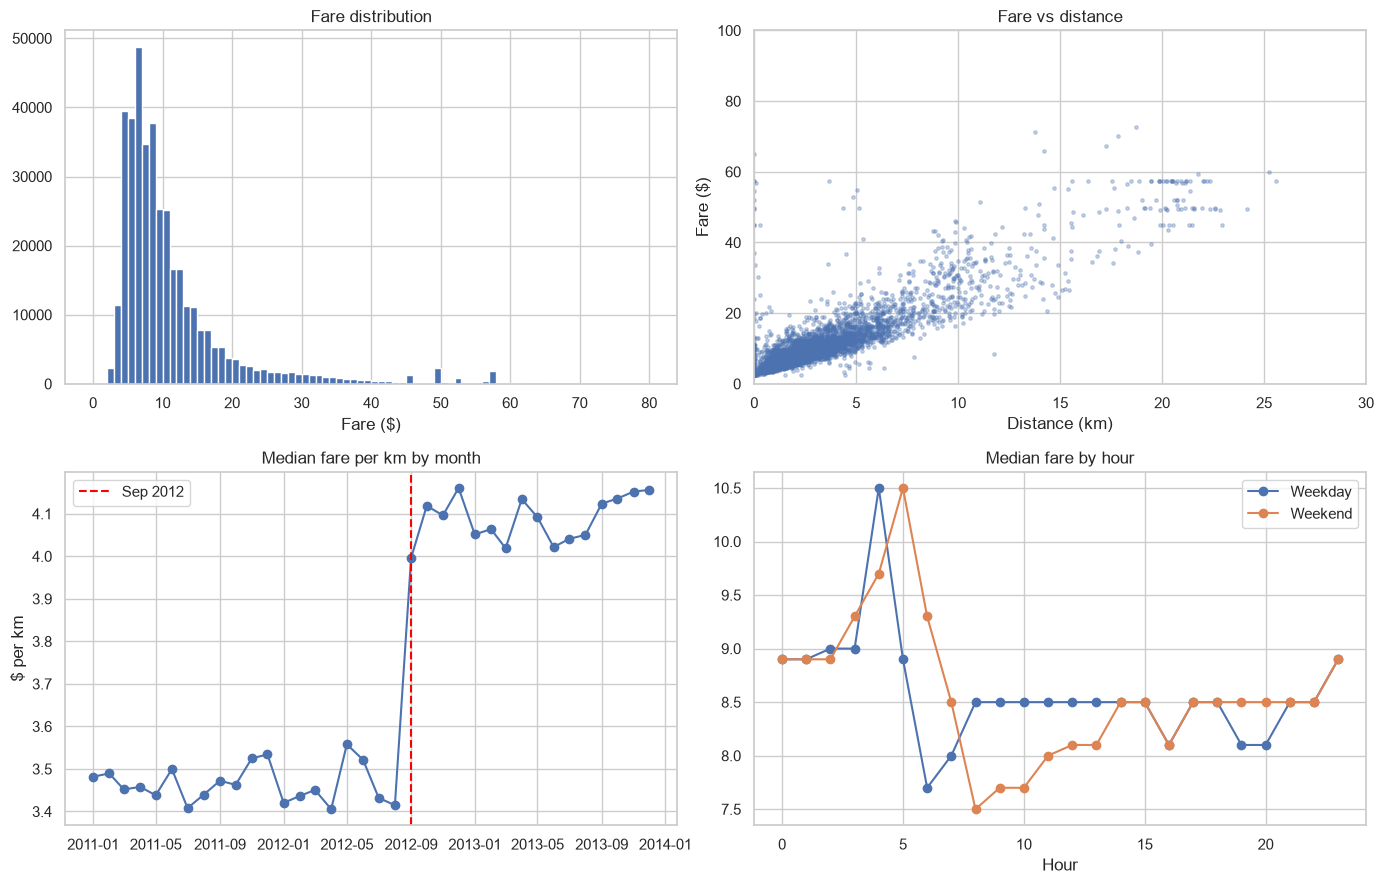

In [34]:
# distance in km between two points given in degrees
def distance_km(lat1, lon1, lat2, lon2):
    # convert each value on its own, so columns and single numbers both work
    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lat2, lon2 = np.radians(lat2), np.radians(lon2)
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

# a copy of the train set with the fare, used for plots only
eda = X_train.copy()
eda["fare"] = y_train

# trip distance and time parts for the plots
eda["distance"] = distance_km(eda["pickup_latitude"], eda["pickup_longitude"],
                              eda["dropoff_latitude"], eda["dropoff_longitude"])
eda["hour"] = eda["pickup_datetime"].dt.hour
eda["weekend"] = eda["pickup_datetime"].dt.dayofweek >= 5
eda["month"] = eda["pickup_datetime"].dt.to_period("M").dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) most fares are small, with a long tail of expensive trips
axes[0, 0].hist(eda["fare"], bins=80, range=(0, 80))
axes[0, 0].set_title("Fare distribution")
axes[0, 0].set_xlabel("Fare ($)")

# 2) fare vs distance on 5,000 trips, because all points would be one blob
sample = eda.sample(5000, random_state=RANDOM_STATE)
axes[0, 1].scatter(sample["distance"], sample["fare"], s=6, alpha=0.3)
axes[0, 1].set_xlim(0, 30)
axes[0, 1].set_ylim(0, 100)
axes[0, 1].set_title("Fare vs distance")
axes[0, 1].set_xlabel("Distance (km)")
axes[0, 1].set_ylabel("Fare ($)")

# 3) fare per km by month, to see the price change in September 2012
trips = eda[eda["distance"] > 0.5]
fare_per_km = (trips["fare"] / trips["distance"]).groupby(trips["month"]).median()
fare_per_km = fare_per_km["2011":"2013"]
axes[1, 0].plot(fare_per_km.index, fare_per_km.values, marker="o")
axes[1, 0].axvline(pd.Timestamp("2012-09-01"), color="red", linestyle="--", label="Sep 2012")
axes[1, 0].set_title("Median fare per km by month")
axes[1, 0].set_ylabel("$ per km")
axes[1, 0].legend()

# 4) fare by hour, weekdays vs weekends
by_hour = eda.groupby(["hour", "weekend"])["fare"].median().unstack()
axes[1, 1].plot(by_hour.index, by_hour[False], marker="o", label="Weekday")
axes[1, 1].plot(by_hour.index, by_hour[True], marker="o", label="Weekend")
axes[1, 1].set_title("Median fare by hour")
axes[1, 1].set_xlabel("Hour")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# trips that start or end within 2 km of JFK airport
pickup_jfk = distance_km(eda["pickup_latitude"], eda["pickup_longitude"], 40.6413, -73.7781) < 2
dropoff_jfk = distance_km(eda["dropoff_latitude"], eda["dropoff_longitude"], 40.6413, -73.7781) < 2
jfk_trips = eda[pickup_jfk | dropoff_jfk]
print("JFK trips:", len(jfk_trips))
print("Most common JFK fares:\n", jfk_trips["fare"].value_counts().head(5))

# impossible fares that label cleaning must handle later
print("\nFares <= 0:", (eda["fare"] <= 0).sum())
print("Fares below $2.5:", (eda["fare"] < 2.5).sum())

**Findings → features**
- **Fare distribution:** skewed to the right; most fares are $5–12 with a peak around $6–7, and there are isolated spikes near $45, $50, $52 and $57 (fixed airport fares) → the model learns `log1p(fare)`.
- **Fare vs distance:** strong, almost linear up to ~10 km, then more spread; a flat band at $50–58 between 15 and 25 km shows fixed JFK fares; some trips with ~0 km have high fares (likely recording errors) → `distance`, `log_distance`, `is_jfk_manhattan`.
- **Fare per km over time:** stable at about $3.45/km until August 2012, then about $4.10/km from September 2012 (+18%) → `after_2012`, `dist_after_2012`.
- **Fare by hour:** highest around 4–5 AM (~$10.5, likely airport trips), lowest at 6 AM on weekdays and 8 AM on weekends, and flat around $8.5 the rest of the day → `hour_sin`, `hour_cos`, `is_weekend`.
- **Label cleaning (Stage 6):** remove fares ≤ 0, fares below $2.50, and fares over $100 per km from the training rows only.

##  Feature Engineering and Preprocessing
**What:** build one pipeline: `TripFeatures` creates the features found in the EDA from the raw inputs, then a `ColumnTransformer` scales the numbers and encodes the text columns, then the model learns `log1p(fare)`.
**Why:** every step that turns raw inputs into model inputs lives inside the pipeline, and it is saved in `fare_pipeline.py` so the Flask app uses the same code.
**Why it matters:** the scaler and encoders are fitted on training rows only, and a raw trip typed by a user goes through exactly the same steps as the training data.

In [35]:
%%writefile fare_pipeline.py
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler

# fixed places in degrees (lat, lon)
JFK = (40.6413, -73.7781)
LGA = (40.7769, -73.8740)
EWR = (40.6895, -74.1745)
MIDTOWN = (40.7580, -73.9855)

# real order of the labels, from worst to best
CAR_ORDER = ["Bad", "Good", "Very Good", "Excellent"]
TRAFFIC_ORDER = ["Flow Traffic", "Dense Traffic", "Congested Traffic"]


# distance in km between two points given in degrees
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))


# builds the EDA features from the raw trip columns
class TripFeatures(BaseEstimator, TransformerMixin):
    # nothing to learn, only fixed formulas
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        out = X.copy()
        plat, plon = out["pickup_latitude"], out["pickup_longitude"]
        dlat, dlon = out["dropoff_latitude"], out["dropoff_longitude"]

        # trip length, and its log because the fare curve bends on long trips
        out["distance"] = haversine_km(plat, plon, dlat, dlon)
        out["log_distance"] = np.log1p(out["distance"])

        # closest end of the trip to each airport and to Midtown
        for name, (la, lo) in {"jfk": JFK, "lga": LGA, "ewr": EWR, "midtown": MIDTOWN}.items():
            out[f"{name}_dist"] = np.minimum(haversine_km(plat, plon, la, lo),
                                             haversine_km(dlat, dlon, la, lo))

        # direction of the trip
        out["bearing"] = np.degrees(np.arctan2(dlon - plon, dlat - plat))

        # time parts from the pickup date
        dt = pd.to_datetime(out["pickup_datetime"])
        out["year"] = dt.dt.year
        out["month"] = dt.dt.month
        out["weekday"] = dt.dt.dayofweek
        out["is_weekend"] = (dt.dt.dayofweek >= 5).astype(int)

        # hour as a circle, because hour 23 is next to hour 0
        out["hour_sin"] = np.sin(2 * np.pi * dt.dt.hour / 24)
        out["hour_cos"] = np.cos(2 * np.pi * dt.dt.hour / 24)

        # the price per km jumped in September 2012
        out["after_2012"] = (dt >= "2012-09-01").astype(int)
        out["dist_after_2012"] = out["distance"] * out["after_2012"]

        # JFK to Manhattan trips have a fixed fare
        pick_jfk = haversine_km(plat, plon, *JFK) < 2
        drop_jfk = haversine_km(dlat, dlon, *JFK) < 2
        pick_mid = haversine_km(plat, plon, *MIDTOWN) < 5
        drop_mid = haversine_km(dlat, dlon, *MIDTOWN) < 5
        out["is_jfk_manhattan"] = ((pick_jfk & drop_mid) | (drop_jfk & pick_mid)).astype(int)

        return out.drop(columns=["pickup_datetime"])


# numeric columns that go to the scaler
NUM_COLS = ["pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude",
            "passenger_count", "distance", "log_distance",
            "jfk_dist", "lga_dist", "ewr_dist", "midtown_dist", "bearing",
            "year", "month", "weekday", "is_weekend", "hour_sin", "hour_cos",
            "after_2012", "dist_after_2012", "is_jfk_manhattan"]


# the full pipeline: features -> scaling and encoding -> model on log1p(fare)
def build_pipeline(model):
    prep = ColumnTransformer([
        ("num", RobustScaler(), NUM_COLS),
        ("ordered", OrdinalEncoder(categories=[CAR_ORDER, TRAFFIC_ORDER],
                                   handle_unknown="use_encoded_value", unknown_value=-1),
         ["Car Condition", "Traffic Condition"]),
        ("weather", OneHotEncoder(handle_unknown="ignore"), ["Weather"]),
    ])
    return Pipeline([
        ("features", TripFeatures()),
        ("prep", prep),
        ("model", TransformedTargetRegressor(regressor=model, func=np.log1p,
                                             inverse_func=np.expm1, check_inverse=False)),
    ])

Overwriting fare_pipeline.py


**Quick check:** run the feature step on a few training rows and fit the pipeline on a small sample, to make sure every step works before training the real models.

In [36]:
from fare_pipeline import TripFeatures, build_pipeline
from sklearn.linear_model import LinearRegression

# features built from 3 raw training rows
display(TripFeatures().transform(X_train.head(3)))

# fit on 5,000 rows and predict 5, just to test that the pipeline runs end to end
test_pipe = build_pipeline(LinearRegression())
test_pipe.fit(X_train.head(5000), y_train.head(5000))
print("Predictions:", test_pipe.predict(X_train.head(5)).round(2))
print("Actual:     ", y_train.head(5).values)

,Car Condition,Weather,Traffic Condition,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance,log_distance,jfk_dist,lga_dist,ewr_dist,midtown_dist,bearing,year,month,weekday,is_weekend,hour_sin,hour_cos,after_2012,dist_after_2012,is_jfk_manhattan
469598,Good,stormy,Dense Traffic,-73.992744,40.763155,-73.979856,40.755680,1,1.367175,0.861697,21.237942,9.221822,17.368357,0.540872,120.113600,2011,1,2,0,8.660254e-01,-0.500000,0,0.0,0
71973,Good,sunny,Dense Traffic,-74.008432,40.730915,-73.965580,40.766160,1,5.328214,1.845018,21.036155,7.803879,14.735578,1.907348,50.563317,2011,3,1,0,-7.071068e-01,-0.707107,0,0.0,0
449702,Excellent,stormy,Dense Traffic,-74.008842,40.709065,-73.989857,40.748102,1,4.626127,1.727421,20.866928,10.269657,14.133670,1.160185,25.935206,2012,4,1,0,1.224647e-16,-1.000000,0,0.0,0


Predictions: [ 6.32 13.46 12.39  7.8  18.59]
Actual:      [ 5.3 13.3 11.7  7.3 17.5]


## Label Cleaning (training rows only)
**What:** flag impossible fares (below $2.50, over $100 for a trip under 0.1 km, or over $100 per km) and remove them from the training part of each cross-validation fold, while the validation part stays as it is.
**Why:** these fares are recording errors, and the model should not learn from them. But a real request has no fare to check, so the validation and test rows must stay untouched.
**Why it matters:** if we cleaned all training rows before cross-validation, the validation folds would be cleaner than real life and the scores would look better than they are. The same 5 folds are reused for every model, so the comparison is fair.

In [37]:
from sklearn.model_selection import KFold
from fare_pipeline import haversine_km

# trip distance, needed to judge if a fare makes sense
train_distance = haversine_km(X_train["pickup_latitude"], X_train["pickup_longitude"],
                              X_train["dropoff_latitude"], X_train["dropoff_longitude"])

# impossible fares: below the $2.50 minimum, $100+ for a tiny trip, or over $100 per km
bad_fare = ((y_train < 2.5)
            | ((train_distance < 0.1) & (y_train > 100))
            | ((train_distance >= 0.1) & (y_train / train_distance > 100))).to_numpy()
print("Impossible fares in train:", bad_fare.sum())

# 5 folds; the bad fares are removed from the training part only
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_folds = [(train_idx[~bad_fare[train_idx]], valid_idx)
            for train_idx, valid_idx in kfold.split(X_train)]

# clean training rows for the final fit after model selection
X_train_clean = X_train[~bad_fare]
y_train_clean = y_train[~bad_fare]
print("Train rows:", len(X_train), "->", len(X_train_clean))

Impossible fares in train: 223
Train rows: 389794 -> 389571


##  Baseline and Model Comparison (cross-validation)
**What:** train Linear Regression (baseline), Random Forest and Gradient Boosting with the same pipeline, and score them with 5-fold cross-validation on the train set.

**Why:** the baseline shows the score a simple model gets, and every model uses the same folds and the same cleaned training rows, so only the model changes.

**Why it matters:** we choose models by evidence, and the test set stays locked until the final check.

In [38]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from fare_pipeline import build_pipeline

# the three models, from the simplest to the most complex
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, min_samples_leaf=10,
                                           max_features=0.5, n_jobs=-1,
                                           random_state=RANDOM_STATE),
    "Gradient Boosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

# the three metrics (sklearn returns errors as negative numbers)
scoring = {"MAE": "neg_mean_absolute_error",
           "RMSE": "neg_root_mean_squared_error",
           "R2": "r2"}

# same pipeline and same folds for every model
results = []
for name, model in models.items():
    scores = cross_validate(build_pipeline(model), X_train, y_train,
                            cv=cv_folds, scoring=scoring)
    results.append({
        "Model": name,
        "MAE": -scores["test_MAE"].mean(),
        "RMSE": -scores["test_RMSE"].mean(),
        "RMSE std": scores["test_RMSE"].std(),
        "R2": scores["test_R2"].mean(),
        "Fit time (s)": scores["fit_time"].mean(),
    })
    print("done:", name)

# lowest RMSE first
cv_results = pd.DataFrame(results).sort_values("RMSE")
cv_results.round(3)

done: Linear Regression
done: Random Forest
done: Gradient Boosting


,Model,MAE,RMSE,RMSE std,R2,Fit time (s)
1,Random Forest,1.607,4.026,0.299,0.824,103.342
2,Gradient Boosting,1.628,4.035,0.304,0.824,6.939
0,Linear Regression,2.130,4.955,0.284,0.734,3.722


**Result:** Random Forest (RMSE 4.026) and Gradient Boosting (RMSE 4.035) are tied, since the gap is far smaller than the fold-to-fold spread (std ≈ 0.30). Both clearly beat the Linear Regression baseline (RMSE 4.955, R² 0.734). Gradient Boosting trains about 15 times faster (7 s vs 103 s per fold). Since neither model wins clearly, both go to tuning.

## Hyperparameter Tuning (RandomizedSearchCV)
**What:** tune Random Forest and Gradient Boosting with RandomizedSearchCV (10 random settings each, 5 folds), then score both tuned models again with the full cross-validation. 

**Why:** random search tries a wide range of settings much faster than trying every combination. The search runs on 100,000 training rows, because Random Forest on all rows would take over an hour.

**Why it matters:** the final choice is made between the best version of each model, using the train set only. Re-scoring on all training rows checks that the settings found on the sample still work on the full data.

**Hyperparameters control how a model learns (tree size, number of trees, learning speed). Tuning looks for the balance between underfitting and overfitting. Since Random Forest and Gradient Boosting were tied, each is tuned before the final choice, so the comparison is between the best version of each model.**

In [40]:
from sklearn.model_selection import RandomizedSearchCV

# 20,000 training rows for the search, to keep it fast
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train), 20_000, replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]
bad_sample = bad_fare[sample_idx]

# bad fares removed from the training part of each fold only
sample_folds = [(train_idx[~bad_sample[train_idx]], valid_idx)
                for train_idx, valid_idx in kfold.split(X_sample)]

# settings to try, and how many random settings per model
search_spaces = {
    "Random Forest": (
        RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE),
        {"model__regressor__min_samples_leaf": [5, 10, 20],
         "model__regressor__max_features": [0.3, 0.5, 0.8]},
        5),
    "Gradient Boosting": (
        HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        {"model__regressor__learning_rate": [0.05, 0.1, 0.2],
         "model__regressor__max_iter": [200, 300, 500],
         "model__regressor__max_leaf_nodes": [15, 31, 63],
         "model__regressor__min_samples_leaf": [10, 20, 50]},
        10),
}

best_params = {}
tuned_results = []
for name, (model, space, n_iter) in search_spaces.items():
    # verbose shows progress; refit=False because the final fit happens in Stage 9
    search = RandomizedSearchCV(build_pipeline(model), space, n_iter=n_iter, cv=sample_folds,
                                scoring="neg_root_mean_squared_error",
                                refit=False, verbose=1, random_state=RANDOM_STATE)
    search.fit(X_sample, y_sample)
    best_params[name] = search.best_params_
    tuned_results.append({"Model": name + " (tuned)", "RMSE": -search.best_score_})
    print(name, "| best settings:", search.best_params_, "| RMSE:", round(-search.best_score_, 3))

# the final 100 trees for Random Forest; the search used 50 only to save time
best_params["Random Forest"]["model__regressor__n_estimators"] = 100

# both models were scored on the same sample and folds, so the lower RMSE wins
winner = min(tuned_results, key=lambda r: r["RMSE"])["Model"]
print("\nChosen by cross-validation:", winner)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Random Forest | best settings: {'model__regressor__min_samples_leaf': 10, 'model__regressor__max_features': 0.8} | RMSE: 4.089
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Gradient Boosting | best settings: {'model__regressor__min_samples_leaf': 10, 'model__regressor__max_leaf_nodes': 31, 'model__regressor__max_iter': 300, 'model__regressor__learning_rate': 0.05} | RMSE: 3.932

Chosen by cross-validation: Gradient Boosting (tuned)


**Result:** after tuning, Gradient Boosting reached RMSE 3.932 against 4.089 for Random Forest, on the same 20,000 rows and the same folds (about 4% lower). The best Gradient Boosting settings are learning_rate 0.05, 300 trees, 31 leaves per tree and at least 10 rows per leaf: smaller learning steps with more trees, which lowers overfitting. The best Random Forest settings are at least 10 rows per leaf and 80% of the features per split. These scores come from a sample, so they are only compared with each other; the final scores on all rows come in Stage 9.

In [42]:
# score each tuned model on all training rows with the same folds as Stage 7
tuned_results = []
for name, (model, _, _) in search_spaces.items():
    pipe = build_pipeline(model).set_params(**best_params[name])
    scores = cross_validate(pipe, X_train, y_train, cv=cv_folds, scoring=scoring)
    tuned_results.append({
        "Model": name + " (tuned)",
        "MAE": -scores["test_MAE"].mean(),
        "RMSE": -scores["test_RMSE"].mean(),
        "RMSE std": scores["test_RMSE"].std(),
        "R2": scores["test_R2"].mean(),
        "Fit time (s)": scores["fit_time"].mean(),
    })
    print("done:", name)

# choose again using the full-data scores
winner = min(tuned_results, key=lambda r: r["RMSE"])["Model"]
print("Chosen by cross-validation:", winner)

# tuned models next to the Stage 7 results
pd.concat([cv_results, pd.DataFrame(tuned_results)]).sort_values("RMSE").round(3)

done: Random Forest
done: Gradient Boosting
Chosen by cross-validation: Gradient Boosting (tuned)


,Model,MAE,RMSE,RMSE std,R2,Fit time (s)
1,Gradient Boosting (tuned),1.602,4.002,0.302,0.827,20.706
0,Random Forest (tuned),1.607,4.022,0.301,0.825,125.564
1,Random Forest,1.607,4.026,0.299,0.824,103.342
2,Gradient Boosting,1.628,4.035,0.304,0.824,6.939
0,Linear Regression,2.130,4.955,0.284,0.734,3.722


## Stage 9: Final Evaluation on the Test Set
**What:** train Linear Regression and the two tuned models on all clean training rows, score them once on the test set, and compare the test RMSE with the cross-validation RMSE.

**Why:** the test set has not been used for any decision, so its score shows how each model will do on new trips. The task asks for MAE, RMSE and R² on the test set for every model.

**Why it matters:** this table is the evidence for choosing the deployed model. If the test RMSE is close to the CV RMSE, nothing leaked from the test set. (CV RMSE for the tuned models comes from the 20,000-row search sample.)

In [44]:
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# the baseline and the two tuned models, all with the same pipeline
final_models = {
    "Linear Regression": build_pipeline(LinearRegression()),
    "Random Forest (tuned)": build_pipeline(
        RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE)
    ).set_params(**best_params["Random Forest"]),
    "Gradient Boosting (tuned)": build_pipeline(
        HistGradientBoostingRegressor(random_state=RANDOM_STATE)
    ).set_params(**best_params["Gradient Boosting"]),
}

# CV RMSE from Stages 7 and 8, to compare with the test RMSE
all_cv = pd.concat([cv_results, pd.DataFrame(tuned_results)])
cv_rmse = dict(zip(all_cv["Model"], all_cv["RMSE"]))

test_results = []
fitted = {}
for name, pipe in final_models.items():
    # train on all clean training rows
    start = time.time()
    pipe.fit(X_train_clean, y_train_clean)
    fit_time = time.time() - start

    # predict the test set once, and time it
    start = time.time()
    pred = pipe.predict(X_test)
    ms_per_trip = (time.time() - start) / len(X_test) * 1000

    fitted[name] = pipe
    test_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
        "CV RMSE": cv_rmse[name],
        "Fit time (s)": fit_time,
        "ms per trip": ms_per_trip,
    })
    print("done:", name)

# the final comparison table (Part A)
test_table = pd.DataFrame(test_results).sort_values("RMSE")
test_table.round(4)

done: Linear Regression
done: Random Forest (tuned)
done: Gradient Boosting (tuned)


,Model,MAE,RMSE,R2,CV RMSE,Fit time (s),ms per trip
2,Gradient Boosting (tuned),1.5902,3.9349,0.8294,4.0016,28.2553,0.0230
1,Random Forest (tuned),1.5884,3.9536,0.8278,4.0224,212.2617,0.0398
0,Linear Regression,2.1285,4.8335,0.7426,4.9553,3.1165,0.0056


### Model Selection Justification
I chose **Gradient Boosting (tuned)** for deployment. It has the lowest test RMSE ($3.93) and the highest R² (0.829), and compared with the Linear Regression baseline it cuts MAE by about 25% ($2.13 → $1.59) and RMSE by about 19% ($4.83 → $3.93).
Random Forest is almost tied on the test set (RMSE $3.95, MAE $1.59), so I also looked at speed: Gradient Boosting trains about 7 times faster (28 s vs 212 s) and predicts each trip about 1.7 times faster, which makes it easier to retrain and better suited to a live app.
Linear Regression is the easiest to explain, but its errors are clearly higher.
For all three models the test RMSE is close to the cross-validation RMSE (for example $3.93 vs $4.00 for Gradient Boosting), which shows the results are stable and nothing leaked from the test set.

In [48]:
import os

# save the model that won in cross-validation, with all its preprocessing
final_pipeline = fitted[winner]
joblib.dump(final_pipeline, "final_pipeline.joblib")
print("Saved:", winner, "| size:", round(os.path.getsize("final_pipeline.joblib") / 1e6, 1), "MB")

# load it back and check it gives the same predictions
loaded = joblib.load("final_pipeline.joblib")
print("Same predictions after loading:",
      np.allclose(loaded.predict(X_test), final_pipeline.predict(X_test)))

# three raw trips, written the way a user would type them
trips = pd.DataFrame([
    {"trip": "Short: Midtown -> Empire State (~1 km)",
     "pickup_latitude": 40.7580, "pickup_longitude": -73.9855,
     "dropoff_latitude": 40.7484, "dropoff_longitude": -73.9857,
     "pickup_datetime": "2013-06-12 09:30"},
    {"trip": "Medium: Midtown -> Wall Street (~6 km)",
     "pickup_latitude": 40.7580, "pickup_longitude": -73.9855,
     "dropoff_latitude": 40.7069, "dropoff_longitude": -74.0113,
     "pickup_datetime": "2014-03-05 14:00"},
    {"trip": "Airport: JFK -> Midtown (fixed fare)",
     "pickup_latitude": 40.6413, "pickup_longitude": -73.7781,
     "dropoff_latitude": 40.7580, "dropoff_longitude": -73.9855,
     "pickup_datetime": "2014-03-05 14:00"},
])

# same simple settings for all three, so only the route changes
trips["pickup_datetime"] = pd.to_datetime(trips["pickup_datetime"])
trips["passenger_count"] = 1
trips["Car Condition"] = "Good"
trips["Traffic Condition"] = "Flow Traffic"
trips["Weather"] = X_train["Weather"].mode()[0]

# same column order as training, then predict with the loaded file
trips["predicted_fare"] = loaded.predict(trips[X_train.columns]).round(2)
trips[["trip", "pickup_datetime", "predicted_fare"]]

Saved: Gradient Boosting (tuned) | size: 1.1 MB
Same predictions after loading: True


,trip,pickup_datetime,predicted_fare
0,Short: Midtown -> Empire State (~1 km),2013-06-12 09:30:00,7.41
1,Medium: Midtown -> Wall Street (~6 km),2014-03-05 14:00:00,20.74
2,Airport: JFK -> Midtown (fixed fare),2014-03-05 14:00:00,58.52


**Result:** the saved file (1.1 MB) gives the same predictions after loading. On raw trips typed by hand it predicts $7.41 for a ~1 km Midtown trip at 9:30 on a weekday, $20.74 for a ~6 km Midtown to Wall Street trip (the real street route is longer than the straight line), and $58.52 for JFK to Midtown, close to the fixed $52 fare plus tolls (about $57.33), the same spike seen in the fare distribution. The pipeline works end to end on raw input, so it is ready for the Flask app.


**Pickup heatmap (train set):** most trips start in Manhattan (red and yellow), fewer in Brooklyn, Queens and the Bronx (blue), with small clusters at the three airports. Almost every pickup falls inside the New York box used in cleaning, so the box keeps real trips and removes only GPS errors.

In [60]:
import folium
from folium.plugins import HeatMap

# 50,000 pickups from the train set
points = X_train.sample(50000, random_state=RANDOM_STATE)[["pickup_latitude", "pickup_longitude"]]

# light grey Esri map, free and needs no API key
nyc_map = folium.Map(
    location=[40.73, -73.85], zoom_start=10,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}",
    attr="Esri, HERE, Garmin, OpenStreetMap contributors")

# smaller circles and a high max_zoom, so only the busiest places turn red
HeatMap(points.values.tolist(), radius=12, blur=15, min_opacity=0.3, max_zoom=14).add_to(nyc_map)

# the three airports
for name, lat, lon in [("JFK", 40.6413, -73.7781), ("LaGuardia", 40.7769, -73.8740), ("Newark", 40.6895, -74.1745)]:
    folium.Marker([lat, lon], tooltip=name, icon=folium.Icon(color="red", icon="plane")).add_to(nyc_map)

# save as a web page and open it in the browser
nyc_map.save("pickup_heatmap.html")
print("Saved: pickup_heatmap.html")

Saved: pickup_heatmap.html
